In [15]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
monthly_df = pd.read_csv('/content/drive/MyDrive/morocco-purchasing-power/hcp_monthly_category_clean.csv')

In [17]:
smig_data = [
    {"date": "2008-01-01", "smig_hourly": 9.66, "smig_monthly": 1800},
    {"date": "2009-01-01", "smig_hourly": 10.64, "smig_monthly": 2110},
    {"date": "2011-07-01", "smig_hourly": 11.70, "smig_monthly": None},
    {"date": "2012-07-01", "smig_hourly": 12.24, "smig_monthly": None},
    {"date": "2014-07-01", "smig_hourly": 12.85, "smig_monthly": 2454},
    {"date": "2015-07-01", "smig_hourly": 13.46, "smig_monthly": 2570.86},
    {"date": "2019-07-01", "smig_hourly": 14.13, "smig_monthly": 2698.83},
    {"date": "2020-07-01", "smig_hourly": 14.81, "smig_monthly": 2828.71},
    {"date": "2022-09-01", "smig_hourly": 15.55, "smig_monthly": 2970.05},
    {"date": "2023-09-01", "smig_hourly": 16.29, "smig_monthly": 3111.39},
    {"date": "2025-01-01", "smig_hourly": 17.10, "smig_monthly": 3260.37},
    {"date": "2026-01-01", "smig_hourly": 17.92, "smig_monthly": 3422.72},
]
smig_df = pd.DataFrame(smig_data)
print(smig_df)
#

          date  smig_hourly  smig_monthly
0   2008-01-01         9.66       1800.00
1   2009-01-01        10.64       2110.00
2   2011-07-01        11.70           NaN
3   2012-07-01        12.24           NaN
4   2014-07-01        12.85       2454.00
5   2015-07-01        13.46       2570.86
6   2019-07-01        14.13       2698.83
7   2020-07-01        14.81       2828.71
8   2022-09-01        15.55       2970.05
9   2023-09-01        16.29       3111.39
10  2025-01-01        17.10       3260.37
11  2026-01-01        17.92       3422.72


In [18]:
smig_df.dtypes

,0
date,object
smig_hourly,float64
smig_monthly,float64


In [19]:
smig_df["date"] = pd.to_datetime(smig_df["date"])
print(smig_df)

         date  smig_hourly  smig_monthly
0  2008-01-01         9.66       1800.00
1  2009-01-01        10.64       2110.00
2  2011-07-01        11.70           NaN
3  2012-07-01        12.24           NaN
4  2014-07-01        12.85       2454.00
5  2015-07-01        13.46       2570.86
6  2019-07-01        14.13       2698.83
7  2020-07-01        14.81       2828.71
8  2022-09-01        15.55       2970.05
9  2023-09-01        16.29       3111.39
10 2025-01-01        17.10       3260.37
11 2026-01-01        17.92       3422.72


In [20]:
monthly_range = pd.date_range(start="2009-01-01", end="2026-07-01", freq="MS")
smig_monthly = pd.DataFrame({"date": monthly_range})

smig_monthly = pd.merge_asof(smig_monthly, smig_df[["date","smig_hourly"]], on="date", direction="backward")
print(smig_monthly.head(15))

         date  smig_hourly
0  2009-01-01        10.64
1  2009-02-01        10.64
2  2009-03-01        10.64
3  2009-04-01        10.64
4  2009-05-01        10.64
5  2009-06-01        10.64
6  2009-07-01        10.64
7  2009-08-01        10.64
8  2009-09-01        10.64
9  2009-10-01        10.64
10 2009-11-01        10.64
11 2009-12-01        10.64
12 2010-01-01        10.64
13 2010-02-01        10.64
14 2010-03-01        10.64


In [21]:
print(smig_monthly.tail(15))

          date  smig_hourly
196 2025-05-01        17.10
197 2025-06-01        17.10
198 2025-07-01        17.10
199 2025-08-01        17.10
200 2025-09-01        17.10
201 2025-10-01        17.10
202 2025-11-01        17.10
203 2025-12-01        17.10
204 2026-01-01        17.92
205 2026-02-01        17.92
206 2026-03-01        17.92
207 2026-04-01        17.92
208 2026-05-01        17.92
209 2026-06-01        17.92
210 2026-07-01        17.92


In [22]:
def fetch_worldbank_indicator(indicator_code, country="MA", start_year=2009, end_year=2026):
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator_code}"
    params = {"format": "json", "date": f"{start_year}:{end_year}", "per_page": 1000}
    resp = requests.get(url, params=params, timeout=15)
    resp.raise_for_status()
    meta, data = resp.json()
    records = [{"year": int(row["date"]), "value": row["value"]} for row in data if row["value"] is not None]
    return pd.DataFrame(records).sort_values("year")

wb_inflation = fetch_worldbank_indicator("FP.CPI.TOTL.ZG")  # annual inflation %

print(wb_inflation)

    year     value
16  2009  0.971863
15  2010  0.993557
14  2011  0.906925
13  2012  1.287122
12  2013  1.880655
11  2014  0.442310
10  2015  1.557907
9   2016  1.635311
8   2017  0.754663
7   2018  1.803917
6   2019  0.303386
5   2020  0.705969
4   2021  1.401959
3   2022  6.657042
2   2023  6.091142
1   2024  0.985257
0   2025  0.701902


In [23]:
wb_cpi_index = fetch_worldbank_indicator("FP.CPI.TOTL")     # CPI index level

In [24]:
print(wb_cpi_index)

    year       value
16  2009   99.016217
15  2010  100.000000
14  2011  100.906925
13  2012  102.205721
12  2013  104.127857
11  2014  104.588425
10  2015  106.217816
9   2016  107.954807
8   2017  108.769503
7   2018  110.731614
6   2019  111.067558
5   2020  111.851660
4   2021  113.419775
3   2022  120.970177
2   2023  128.338641
1   2024  129.603106
0   2025  130.512793


In [25]:
food_cpi = monthly_df[monthly_df["category"]=="Produits alimentaires"][["date","index_curr_period"]].copy()
food_cpi.columns = ["date", "food_index"]
food_cpi["date"] = pd.to_datetime(food_cpi["date"])

merged = pd.merge(food_cpi, smig_monthly, on="date", how="inner")
print(merged.head())
print(merged.tail())


        date  food_index  smig_hourly
0 2026-07-01       125.6        17.92
1 2026-06-01       128.0        17.92
2 2026-05-01       129.1        17.92
3 2026-04-01       131.9        17.92
4 2026-03-01       132.7        17.92
          date  food_index  smig_hourly
172 2010-03-01       116.0        10.64
173 2010-02-01       112.3        10.64
174 2010-01-01       110.1        10.64
175 2009-12-01       113.0        10.64
176 2009-11-01       110.9        10.64


In [26]:
def build_pp_index(df):
    df = df.sort_values("date").reset_index(drop=True)  # force ascending, defensively
    base_food = df["food_index"].iloc[0]
    base_smig = df["smig_hourly"].iloc[0]
    df["food_index_rebased"] = df["food_index"] / base_food * 100
    df["smig_rebased"] = df["smig_hourly"] / base_smig * 100
    df["purchasing_power_index"] = df["smig_rebased"] / df["food_index_rebased"] * 100
    return df

rebase_date = pd.Timestamp("2020-04-01")
pre = build_pp_index(merged[merged["date"] < rebase_date])
post = build_pp_index(merged[merged["date"] >= rebase_date])

# Verify: the very first row of each should now show exactly 100 for both series
print(pre.head()[["date","food_index_rebased","smig_rebased", "purchasing_power_index"]])
print(post.head()[["date","food_index_rebased","smig_rebased", "purchasing_power_index"]])

        date  food_index_rebased  smig_rebased  purchasing_power_index
0 2009-11-01          100.000000         100.0              100.000000
1 2009-12-01          101.893598         100.0               98.141593
2 2010-01-01           99.278629         100.0              100.726612
3 2010-02-01          101.262399         100.0               98.753339
4 2010-03-01          104.598738         100.0               95.603448
        date  food_index_rebased  smig_rebased  purchasing_power_index
0 2020-04-01          100.000000    100.000000              100.000000
1 2020-05-01           99.420290    100.000000              100.583090
2 2020-06-01           98.164251    100.000000              101.870079
3 2020-07-01           96.618357    104.812456              108.480892
4 2020-08-01           99.903382    104.812456              104.913822


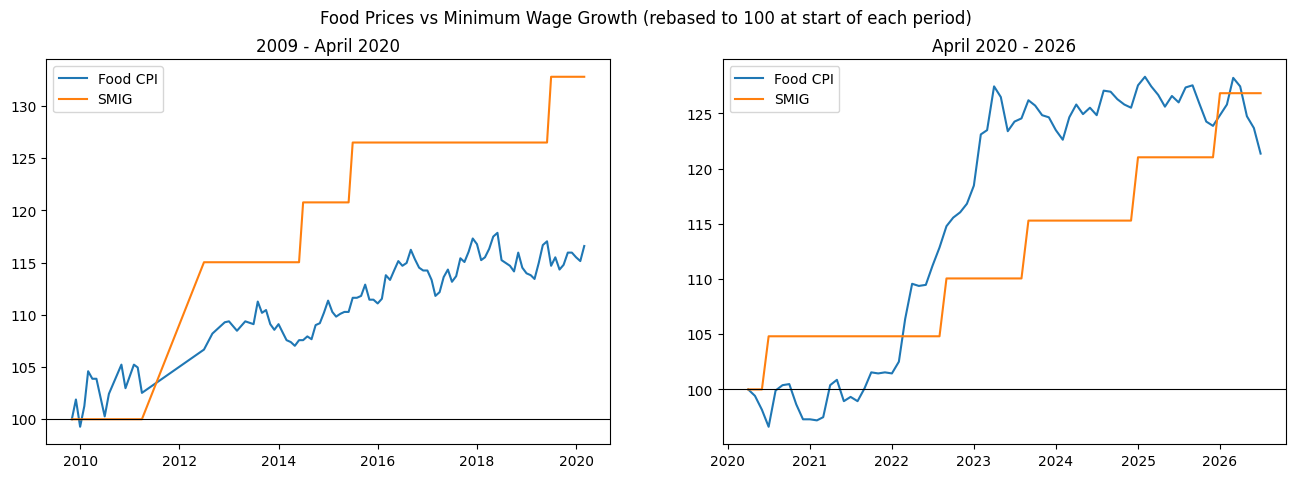

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16,5), sharey=False)

axes[0].plot(pre["date"], pre["food_index_rebased"], label="Food CPI")
axes[0].plot(pre["date"], pre["smig_rebased"], label="SMIG")
axes[0].axhline(100, color="black", linewidth=0.8)
axes[0].set_title("2009 - April 2020")
axes[0].legend()

axes[1].plot(post["date"], post["food_index_rebased"], label="Food CPI")
axes[1].plot(post["date"], post["smig_rebased"], label="SMIG")
axes[1].axhline(100, color="black", linewidth=0.8)
axes[1].set_title("April 2020 - 2026")
axes[1].legend()

plt.suptitle("Food Prices vs Minimum Wage Growth (rebased to 100 at start of each period)")
plt.show()

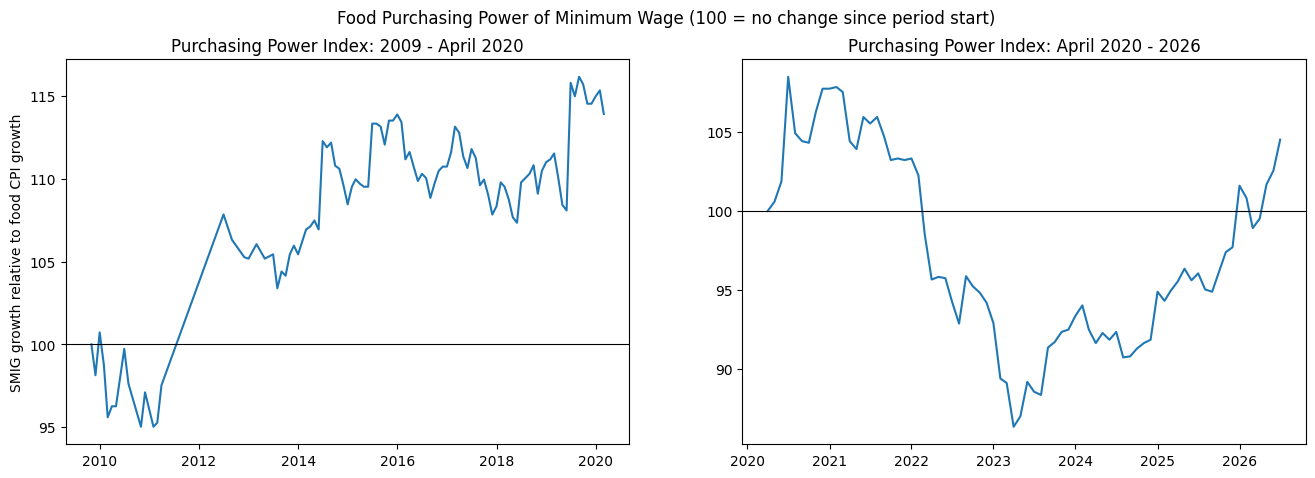

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

axes[0].plot(pre["date"], pre["purchasing_power_index"])
axes[0].axhline(100, color="black", linewidth=0.8)
axes[0].set_title("Purchasing Power Index: 2009 - April 2020")
axes[0].set_ylabel("SMIG growth relative to food CPI growth")

axes[1].plot(post["date"], post["purchasing_power_index"])
axes[1].axhline(100, color="black", linewidth=0.8)
axes[1].set_title("Purchasing Power Index: April 2020 - 2026")

plt.suptitle("Food Purchasing Power of Minimum Wage (100 = no change since period start)")
plt.show()

In [29]:
smig_df.to_csv("/content/drive/MyDrive/morocco-purchasing-power/smig_history.csv", index=False)

## **Summary**
## Key Findings — SMIG & Purchasing Power

**Data sources:** HCP food CPI (this project's own scraped data), SMIG minimum wage history (based on official decrees and checked with several sources), World Bank general inflation/CPI (context only).

**2009 – April 2020:** Minimum wage (SMIG) grew significantly faster than food prices. As a result, the purchasing power of the minimum wage increased by about 15% compared with 2009.

**April 2020 – 2026:** A more volatile period. Purchasing power increased briefly in 2020 because food prices fell while the SMIG stayed the same, then fell sharply through 2022 into early 2023 — losing roughly 13-14% of its value. At its lowest point, purchasing power had lost about 13–14% of its value because food prices increased faster than wages during the global inflation period.
Since then, purchasing power has improved. By 2026, it had recovered to around 104–105% of its April 2020 level. This recovery was helped by SMIG increases in September 2023, January 2025, and January 2026


***Important note:*** In April 2020, the IPC changed its base year from 2006 to 2017. Because of this change, the two periods cannot be combined into one continuous purchasing-power series. Each period is calculated separately, with 100 as the starting point